In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pymc as pm
import arviz as az 
plt.style.use("ggplot")

In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [6]:
from datetime import datetime

def parse_date(date):
    try:
        return datetime.strptime(date, "%d-%b-%y")
    except ValueError:
        return datetime.strptime(date, "%b %d, %Y")

df["Date"] = df["Date"].apply(parse_date)

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [7]:
df["Log_Return"] = np.log(df["Price"] / df["Price"].shift(1))

df.head()

,Date,Price,Log_Return
0,1987-05-20,18.63,NaN
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612


In [8]:
df = df.dropna().reset_index(drop=True)

df.head()

,Date,Price,Log_Return
0,1987-05-21,18.45,-0.009709
1,1987-05-22,18.55,0.005405
2,1987-05-25,18.60,0.002692
3,1987-05-26,18.63,0.001612
4,1987-05-27,18.60,-0.001612


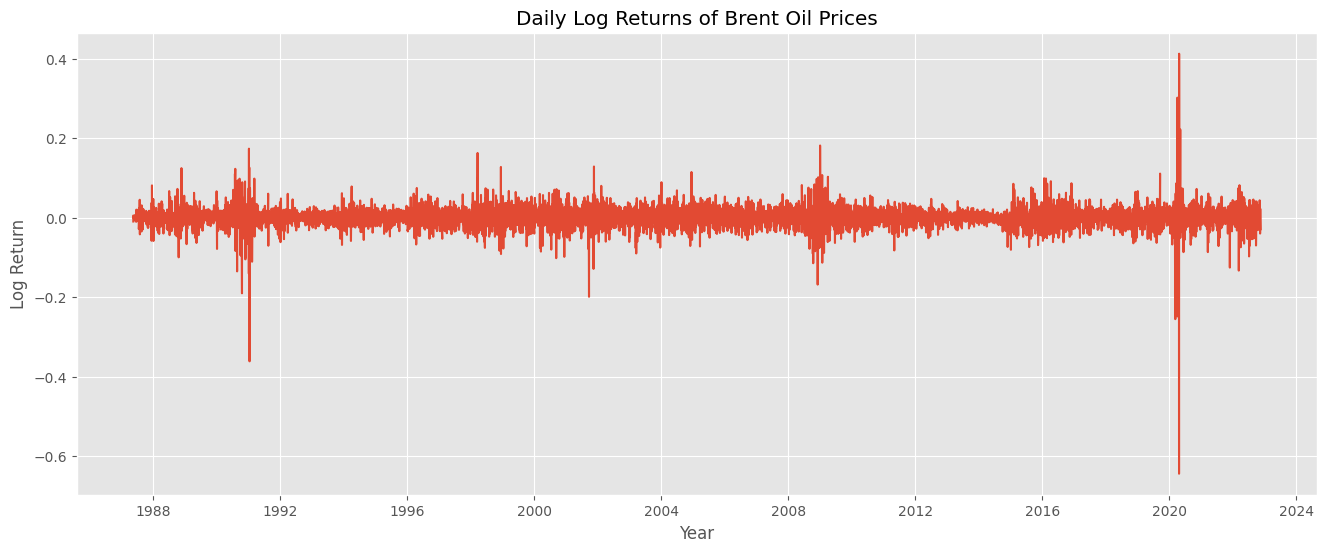

In [9]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Log_Return"])

plt.title("Daily Log Returns of Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

### Log Returns Analysis

Log returns transform the original price series into percentage-like daily changes, reducing the influence of long-term trends. Compared with raw prices, the log return series fluctuates around zero and provides a more suitable input for statistical modeling. Periods with large positive and negative returns indicate episodes of heightened market volatility, which are often associated with major geopolitical and economic events.

In [10]:
result = adfuller(df["Log_Return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -16.427113494485866
p-value: 2.4985801611431036e-29
Critical Values:
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [11]:
# Use the Date column as the index
monthly_df = df.set_index("Date").resample("M")["Price"].mean().reset_index()

monthly_df.head()

C:\Users\ekram\AppData\Local\Temp\ipykernel_8888\1698275368.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = df.set_index("Date").resample("M")["Price"].mean().reset_index()


,Date,Price
0,1987-05-31,18.572857
1,1987-06-30,18.860476
2,1987-07-31,19.856522
3,1987-08-31,18.979524
4,1987-09-30,18.313182


In [12]:
monthly_df.shape

(427, 2)

Visualize Monthly Prices

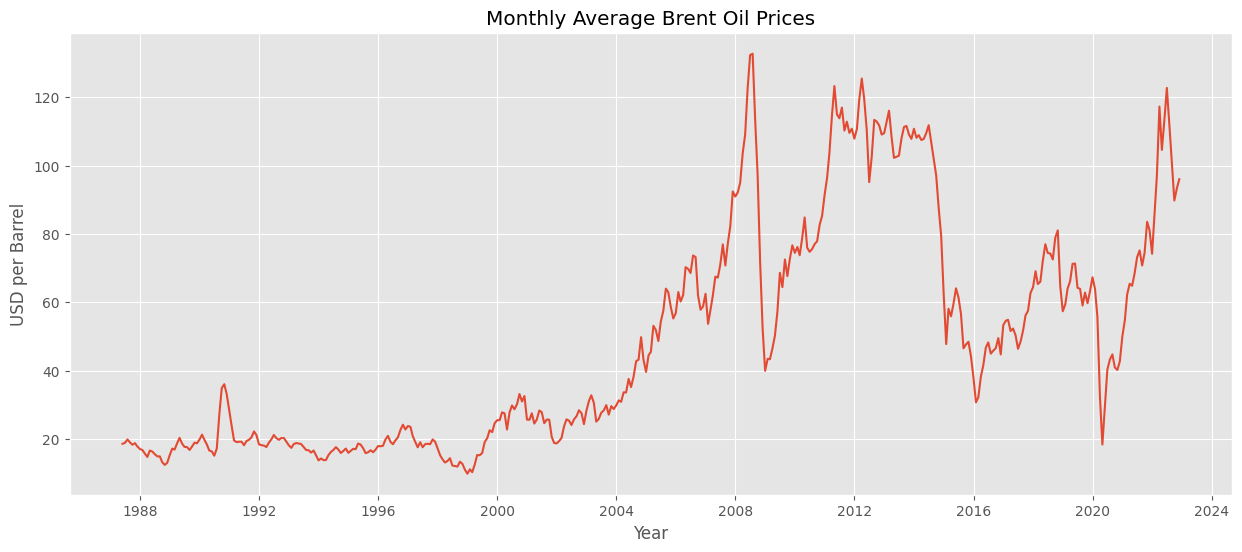

In [13]:
plt.figure(figsize=(15,6))

plt.plot(monthly_df["Date"], monthly_df["Price"])

plt.title("Monthly Average Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("USD per Barrel")

plt.grid(True)

plt.show()

Prepare Data for PyMC

In [14]:
price = monthly_df["Price"].values

n = len(price)

Build the Bayesian Change Point Model

In [15]:
with pm.Model() as change_point_model:

    # Unknown change point
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n - 1
    )

    # Mean before change
    mu_1 = pm.Normal(
        "mu_1",
        mu=np.mean(price),
        sigma=np.std(price)
    )

    # Mean after change
    mu_2 = pm.Normal(
        "mu_2",
        mu=np.mean(price),
        sigma=np.std(price)
    )

    # Common standard deviation
    sigma = pm.HalfNormal(
        "sigma",
        sigma=np.std(price)
    )

    # Mean switches after tau
    mu = pm.math.switch(
        np.arange(n) < tau,
        mu_1,
        mu_2
    )

    # Likelihood
    pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=price
    )

Sample from the Posterior

In [16]:
with change_point_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2131 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [17]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,214.216,1.946,211.000,218.000,0.068,0.060,813.0,859.0,1.01
mu_1,21.469,1.305,19.207,24.119,0.023,0.021,3339.0,2876.0,1.00
mu_2,75.700,1.332,73.228,78.206,0.024,0.020,3020.0,2565.0,1.00
sigma,18.643,0.647,17.494,19.885,0.011,0.010,3696.0,2878.0,1.00


In [18]:
tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.median(tau_samples))

print("Estimated Change Point Index:", estimated_tau)

print("Estimated Date:", monthly_df.iloc[estimated_tau]["Date"])

Estimated Change Point Index: 214
Estimated Date: 2005-03-31 00:00:00


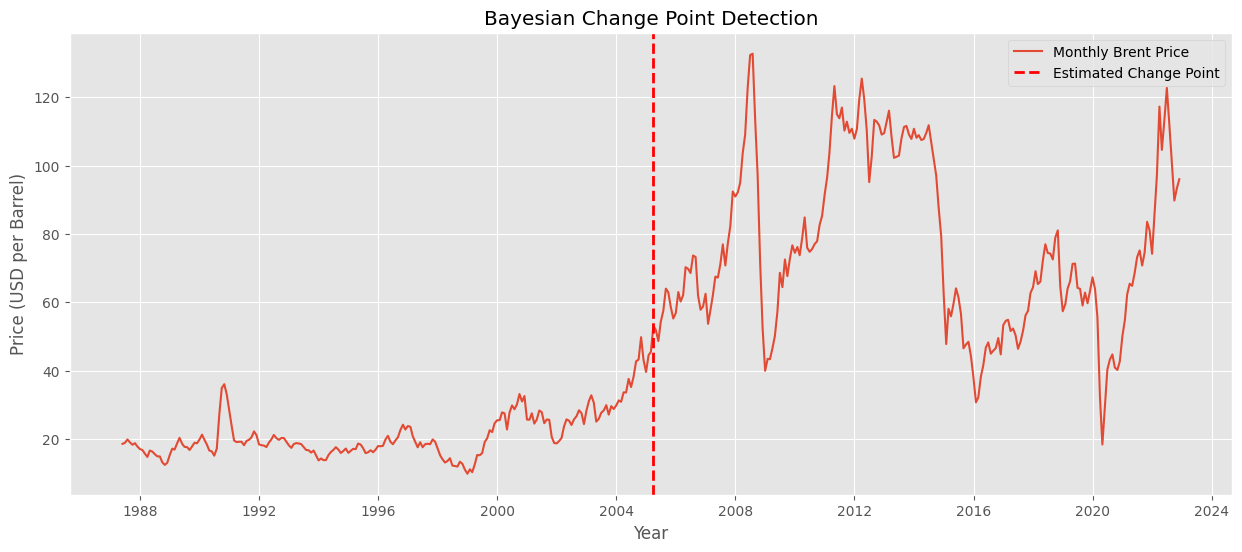

In [19]:
plt.figure(figsize=(15,6))

plt.plot(monthly_df["Date"], monthly_df["Price"], label="Monthly Brent Price")

plt.axvline(
    monthly_df.iloc[estimated_tau]["Date"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Change Point"
)

plt.title("Bayesian Change Point Detection")

plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")

plt.legend()
plt.grid(True)

plt.show()

Convergence summary

In [20]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,214.216,1.946,211.000,218.000,0.068,0.060,813.0,859.0,1.01
mu_1,21.469,1.305,19.207,24.119,0.023,0.021,3339.0,2876.0,1.00
mu_2,75.700,1.332,73.228,78.206,0.024,0.020,3020.0,2565.0,1.00
sigma,18.643,0.647,17.494,19.885,0.011,0.010,3696.0,2878.0,1.00


Trace plots

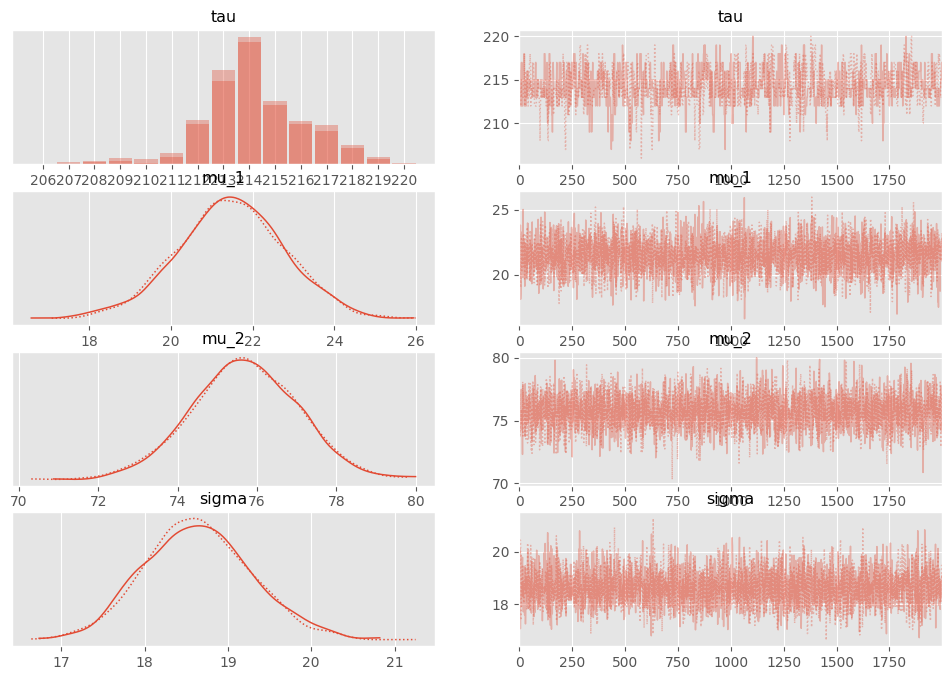

In [21]:
az.plot_trace(trace)
plt.show()

Find the estimated change point

In [23]:
tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.median(tau_samples))

print("Estimated Change Point Index:", estimated_tau)
print("Estimated Date:", monthly_df.iloc[estimated_tau]["Date"])

Estimated Change Point Index: 214
Estimated Date: 2005-03-31 00:00:00


Plot the detected change point

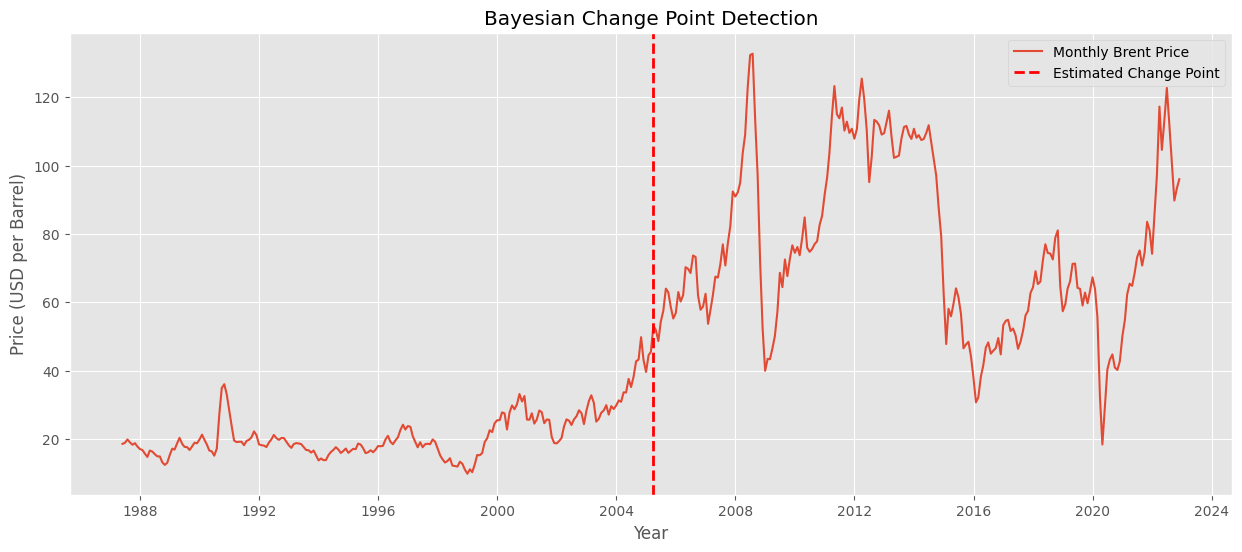

In [24]:
plt.figure(figsize=(15,6))

plt.plot(monthly_df["Date"], monthly_df["Price"], label="Monthly Brent Price")

plt.axvline(
    monthly_df.iloc[estimated_tau]["Date"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Change Point"
)

plt.title("Bayesian Change Point Detection")
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Build monthly log returns from monthly prices
monthly_df["log_price"] = np.log(monthly_df["Price"])
monthly_df["log_return"] = monthly_df["log_price"].diff()
monthly_returns = monthly_df["log_return"].dropna().values

n = len(monthly_returns)
with pm.Model() as return_model:
    tau_r = pm.DiscreteUniform("tau", lower=0, upper=n-1)
    mu_1_r = pm.Normal("mu_1", mu=0, sigma=0.1)
    mu_2_r = pm.Normal("mu_2", mu=0, sigma=0.1)
    sigma_r = pm.HalfNormal("sigma", sigma=0.1)
    idx = np.arange(n)
    mu_t = pm.math.switch(idx <= tau_r, mu_1_r, mu_2_r)
    pm.Normal("obs", mu=mu_t, sigma=sigma_r, observed=monthly_returns)
    trace_returns = pm.sample(draws=2000, tune=1000, target_accept=0.95, random_seed=42)

az.summary(trace_returns, var_names=["tau","mu_1","mu_2","sigma"])

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 3841 seconds.
There were 81 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,252.060,147.314,15.000,425.000,19.723,4.431,73.0,198.0,1.01
mu_1,0.001,0.012,-0.018,0.016,0.000,0.002,589.0,347.0,1.03
mu_2,0.012,0.027,-0.019,0.077,0.003,0.002,68.0,183.0,1.03
sigma,0.100,0.003,0.094,0.106,0.000,0.000,435.0,1230.0,1.00


In [26]:
tau_r_samples = trace_returns.posterior["tau"].values.flatten()
estimated_tau_r = int(np.median(tau_r_samples))
change_date_returns = monthly_df.iloc[estimated_tau_r]["Date"]
print("Change point (log-return model):", change_date_returns)
print("Change point (price model):     ", monthly_df.iloc[214]["Date"])  # your original result

Change point (log-return model): 2011-05-31 00:00:00
Change point (price model):      2005-03-31 00:00:00


In [27]:
events_df = pd.read_csv("../data/external/key_events.csv", parse_dates=["start_date"])

change_date = pd.Timestamp(change_date_returns)
events_df["days_diff"] = (events_df["start_date"] - change_date).dt.days.abs()
closest = events_df.sort_values("days_diff").iloc[0]
print(closest)
print(f"\n{closest['days_diff']} days from detected change point")

event_id                                                       8
start_date                                   2011-02-15 00:00:00
event_name                        Arab Spring / Libyan Civil War
category                                                Conflict
description    Political uprisings across the Middle East and...
days_diff                                                    105
Name: 7, dtype: object

105 days from detected change point


quantify the price-level impact in dollars

In [ ]:
mu_1_price = 21.469  
mu_2_price = 75.700
pct_change = (mu_2_price - mu_1_price) / mu_1_price * 100
print(f"Average price before: ${mu_1_price:.2f}")
print(f"Average price after:  ${mu_2_price:.2f}")
print(f"Change: {pct_change:.1f}%")

Average price before: $21.47
Average price after:  $75.70
Change: 252.6%


In [29]:
import json

results = {
    "price_model": {
        "tau_date": "2005-03-31",
        "mu_1": 21.469,
        "mu_2": 75.700,
        "pct_change": round(pct_change, 1),
        "r_hat_ok": True
    },
    "return_model": {
        "tau_date": str(change_date_returns.date()),
        "nearest_event": "Arab Spring / Libyan Civil War",
        "days_from_event": 105,
        "note": "Wide credible interval (HDI 15-425 months) and low ESS (~70) indicate low confidence in this specific date; included for completeness, not as a strong finding."
    }
}

with open("../reports/change_point_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved.")

Saved.
